<a target="_blank" href="https://colab.research.google.com/github/dcintlab/WignerCamp2026/blob/main/EdgeDetectionConvolution/conv2d_function.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 📘 Convolution in PyTorch: `torch.nn.functional.conv2d`

This notebook demonstrates how 2D convolution works in PyTorch using a real image.

We will:

- Load and display an image
- Convert it into a PyTorch tensor
- Apply convolution filters
- Explain all key parameters (stride, padding, dilation, groups)
- Show how to preserve image shape (“same convolution”)

## 1. Setup

In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My Drive/Colab Notebooks/WignerCamp2026
except:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

Running on Local computer


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

## 2. Loading and displaying the image

We use PIL to open the image and matplotlib to visualize it.

(327, 325)


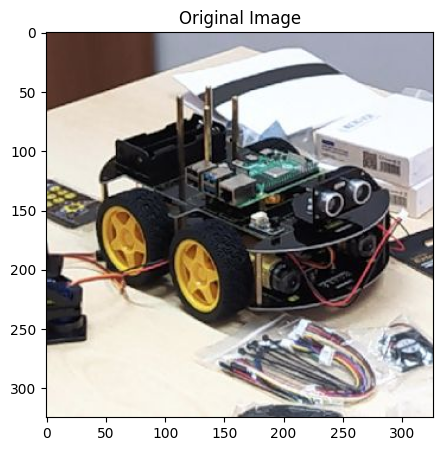

In [ ]:
if IN_COLAB:
    img_path = "wigner-robot.jpg"
else:
    img_path = "../img/wigner-robot.jpg"

img = Image.open(img_path).convert("RGB")
print(img.size)

plt.figure(figsize=(5,5))
plt.title("Original Image")
plt.imshow(img);
#plt.axis("off");

## 3. Convert image to PyTorch tensor

PyTorch expects image tensors in shape:

> (N, C, H, W)

- `N` = batch size
- `C` = channels (RGB = 3)
- `H, W` = height and width

In [4]:
transform = T.ToTensor()
x = transform(img).unsqueeze(0)  # add batch dimension

print("Tensor shape:", x.shape)

Tensor shape: torch.Size([1, 3, 325, 327])


## 4. What is convolution?

A convolution applies a **small matrix (kernel/filter)** over the image to extract features like:

- edges
- textures
- blur
- patterns

We define a simple edge detection kernel (Sobel filter).

In [5]:
kernel = torch.zeros(1, 3, 3, 3)

kernel[0, 0] = torch.tensor([[-1, 0, 1],
                             [-2, 0, 2],
                             [-1, 0, 1]])  # R

kernel[0, 1] = kernel[0, 0]  # G

kernel[0, 2] = kernel[0, 0]  # B

print("Kernel shape:", kernel.shape)

Kernel shape: torch.Size([1, 3, 3, 3])


Note: kernel shape is `(out_channels, in_channels, kH, kW)`.

## 5. Applying `conv2d`

In [6]:
y = F.conv2d(x, kernel, stride=1, padding=0)

print("Output shape:", y.shape)

Output shape: torch.Size([1, 1, 323, 325])


## 6. Visualizing the result

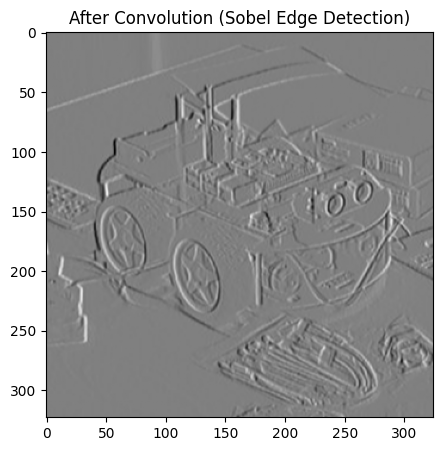

In [7]:
out = y.squeeze().detach().numpy()

plt.figure(figsize=(5,5))
plt.title("After Convolution (Sobel Edge Detection)")
plt.imshow(out, cmap="gray");

## ⚙️ 7. Understanding conv2d parameters

### 📌 1. stride

Controls how far the kernel moves each step.

- `stride=1` → detailed output (slow, large output)
- `stride=2` → downsampling (smaller output)

torch.Size([1, 1, 108, 109])


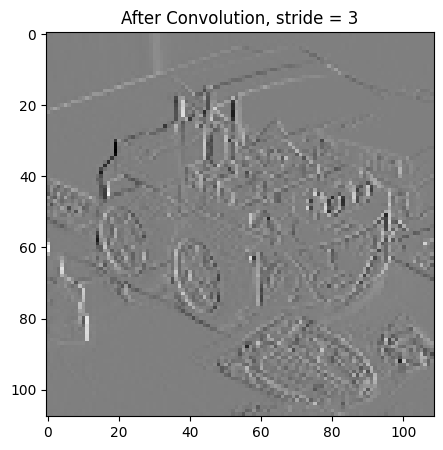

In [8]:
y_stride2 = F.conv2d(x, kernel, stride=3)
print(y_stride2.shape)

out = y_stride2.squeeze().detach().numpy()
plt.figure(figsize=(5,5))
plt.title("After Convolution, stride = 3")
plt.imshow(out, cmap="gray");

Effect: reduces spatial resolution.

### 📌 2. padding

Adds borders around the image.

- `padding=0` → output shrinks
- `padding=1` (for 3×3 kernel) → preserves more structure

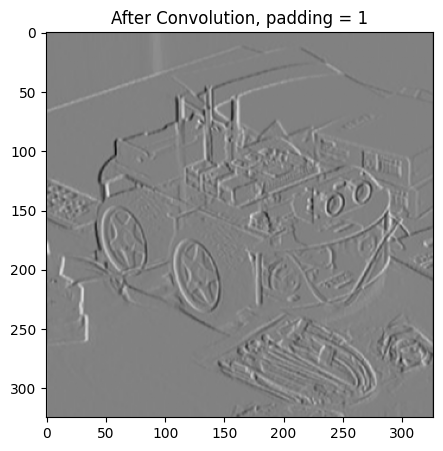

In [9]:
y_pad = F.conv2d(x, kernel, stride=1, padding=1)

out = y_pad.squeeze().detach().numpy()
plt.figure(figsize=(5,5))
plt.title("After Convolution, padding = 1")
plt.imshow(out, cmap="gray");

### 📌 3. dilation

Spaces out kernel elements.

- `dilation=1` → normal kernel
- `dilation=2` → kernel "sees" a larger area

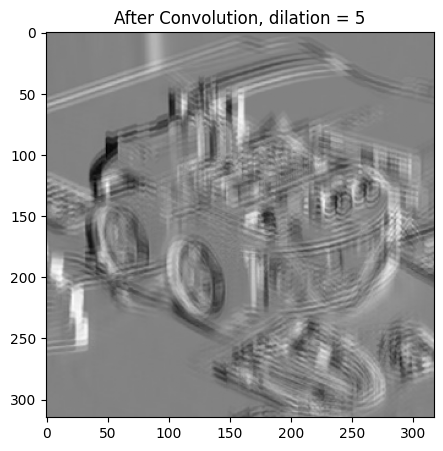

In [10]:
y_dilated = F.conv2d(x, kernel, dilation=5)

out = y_dilated.squeeze().detach().numpy()
plt.figure(figsize=(5,5))
plt.title("After Convolution, dilation = 5")
plt.imshow(out, cmap="gray");

### 📌 4. groups

Controls connectivity between input and output channels.

- `groups=1` → standard convolution
- `groups=in_channels` → depthwise convolution

Example: depthwise convolution

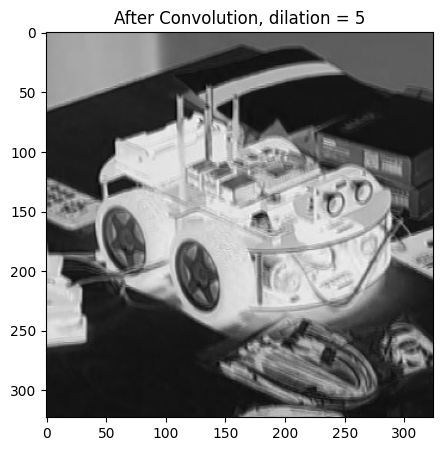

In [11]:
torch.manual_seed(0)
depthwise_kernel = torch.randn(3, 1, 3, 3)  # 3 input channels, separate filter each

y_depthwise = F.conv2d(x, depthwise_kernel, groups=3)

out = y_depthwise.squeeze().detach().numpy()
plt.figure(figsize=(5,5))
plt.title("After Convolution, dilation = 5")
plt.imshow(out[0, :, :], cmap="gray");

## 📏 8. Keeping the same image size (“same convolution”)

**Example:**

For a 3×3 kernel:

- output shrinks by 2 pixels per dimension (if padding=0)

---

### ✔️ Solution 1: manual padding

For a 3×3 kernel:

In [12]:
pad = 1
y_same = F.conv2d(x, kernel, padding=pad)
print(y_same.shape)

torch.Size([1, 1, 325, 327])


This preserves spatial dimensions.

### ✔️ Solution 2: PyTorch "same" padding (newer versions)

In [13]:
y_same2 = F.conv2d(x, kernel, padding="same")
print(y_same2.shape)

torch.Size([1, 1, 325, 327])


### ⚖️ Tradeoffs

#### ✔️ Using padding (“same convolution”)

Pros:

- Keeps image size constant
- Easier to stack layers in deep networks

Cons:

- Artificial border values (zero padding artifacts)
- Can distort edges near image boundary

#### ❌ No padding (“valid convolution”)

Pros:

- Pure signal (no artificial pixels)
- Cleaner mathematical interpretation

Cons:

- Shrinks image each layer
- Harder to build deep networks without size loss

## 🧠 9. Summary

You now know how to:

- Load images as tensors
- Apply `conv2d`
- Use different kernels
- Control output shape using:
    - stride
    - padding
    - dilation
    - groups
- Preserve image size using padding strategies